In [1]:
import os
import sys
import subprocess
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset, Dataset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm import tqdm
import tarfile
from transformers import AutoImageProcessor, AutoModel
import random
import urllib
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings

In [2]:
# --- SETUP ----
DEBUG = False

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", message=".*Torch was not compiled with flash attention.*")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 45390
PROJECT_PATH = os.path.abspath(os.path.join(".."))


REPO_NAME = "ssl-data-curation"
REPO_URL = "https://github.com/facebookresearch/ssl-data-curation.git"
REPO_PATH = os.path.join(os.getcwd(),f"../{REPO_NAME}/")
def setup_repo():
    if not os.path.exists(REPO_PATH):
        print(f"--- Cloning repository {REPO_NAME}... ---")
        os.chdir(os.path.join(os.getcwd(),".."))
        subprocess.run(["git", "clone", REPO_URL], check=True)
        os.chdir(os.path.join(os.getcwd(),"Code"))

    src_path = os.path.join(REPO_PATH, "src")

    if src_path not in sys.path:
        sys.path.insert(0, src_path)
    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)
    print("--- Repository paths configured ---")

# przygotowanie danych (imagenette) ---
DATA_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
DATA_DIR = "imagenette2-320"
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(),f"../{DATA_DIR}/"))
def prepare_data():
    if not os.path.exists(DATA_PATH):
        os.chdir(os.path.join(os.getcwd(),".."))
        if not os.path.exists("imagenette.tgz"):
            print("--- Downloading Imagenette dataset (320px)... ---")
            urllib.request.urlretrieve(DATA_URL, "imagenette.tgz")
        with tarfile.open("imagenette.tgz", "r:gz") as tar:
            tar.extractall(path=PROJECT_PATH)

In [3]:
prepare_data()
setup_repo()

from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg
from src import hierarchical_sampling as hs

--- Repository paths configured ---


In [4]:
# ----------------- FUNKCJE POMOCNICZE ----------------------
class ResnetTransform:
    def __init__(self):
        self.transfrom = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    def __call__(self,img):
        return self.transfrom(img)

def get_resnet50_embedings(dataset,batch_size=128):
    extractor = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).to(device)
    extractor.fc = nn.Identity()
    extractor.eval()
    
    all_features = []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        feature_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,num_workers=0)
        for imgs, _ in tqdm(feature_loader, desc="Feature extraction"):
            feat = extractor(imgs.to(device))
            all_features.append(feat.cpu())            
    
    return torch.cat(all_features).to(device)

class DinoTransform:
    def __init__(self, processor= AutoImageProcessor.from_pretrained('facebook/dinov2-large') ):
        self.processor = processor
    def __call__(self, img):
        return self.processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)

def get_dino_embedings(dataset,batch_size=128):
    #dataset need proper tronsform (DinoTransform)

    extractor = AutoModel.from_pretrained('facebook/dinov2-large')
    extractor.eval()
    extractor.to(device)
    all_embedings = []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        extr_loader = DataLoader(dataset,batch_size=batch_size,shuffle=False,num_workers=0)
        for imgs,_ in tqdm(extr_loader, desc="Feature extraction"):
            imgs = imgs.to(device)
            outputs = extractor(imgs)
            embedings = outputs.last_hidden_state[:,0,:]
            all_embedings.append(embedings.cpu())

    return torch.cat(all_embedings).to(device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# pentla trenująca
def train_model(model, criterion, optimizer, train_loader, test_loader, device, title, epochs=5,
                 epoch_tqdm=False, loader_tqdm=True):
    #zwraca (float,losses)

    print(f"\n[TRENING] Start: {title}")

    criterion = criterion
    optimizer = optimizer
    skipped_steps_counter = 0
    scaler = torch.amp.GradScaler("cuda")
    losses = []

    epoch_progress = range(epochs)
    if epoch_tqdm:
        epoch_progress = tqdm(range(epochs), desc='Epochs')


    for epoch in epoch_progress:
        model.train()
        running_loss = 0.0
        loader_progress = train_loader
        if loader_tqdm:
            loader_progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}")
                                   
        for imgs, labels in loader_progress:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none = True)
            with torch.amp.autocast("cuda"):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()

            #makeing a step and checking wheter scaler made fp16 overflow
            old_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            new_scale = scaler.get_scale()
            # if old_scale != new_scale:
            #     skipped_steps_counter+=1
            #     print(f"Step skipped, scale reduced from {old_scale} -> {new_scale} (batch was futile)")
            running_loss += loss.item()
        losses.append(running_loss)

    # Ewaluacja
    model.eval()
    correct = 0
    total = 0
    with torch.inference_mode():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"[RESULT] {title} Accuracy: {accuracy:.2f}%")
    return accuracy, losses

### Linear probe vs fine-tune

In [5]:
print(f"Running on device: {device}")
train_dataset = datasets.ImageFolder(os.path.join(DATA_PATH, 'train'), transform=ResnetTransform())
test_dataset = datasets.ImageFolder(os.path.join(DATA_PATH, 'val'), transform=ResnetTransform())
test_loader = DataLoader(test_dataset,batch_size=128,shuffle=False,num_workers=0)
NUM_CLASSES = 10

Running on device: cuda


In [6]:
print("\n--- Feature extraction and hierarchical k-means (dino) ---")
set_seed(SEED)
train_dataset_dino = datasets.ImageFolder(os.path.join(DATA_PATH,"train"), transform=DinoTransform())
dino_embedings = get_dino_embedings(train_dataset_dino).float()
clusters_dino = hkmg.hierarchical_kmeans_with_resampling(
    data=dino_embedings,                                                                           
    n_clusters=[100, 10],
    n_levels=2,
    sample_sizes=[65, 650],
    verbose=False,
)
cl_dino = HierarchicalCluster.from_dict(clusters_dino)


--- Feature extraction and hierarchical k-means (dino) ---


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Feature extraction: 100%|██████████| 74/74 [01:45<00:00,  1.42s/it]


Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  7.58it/s]


Linear Probing vs Fine-Tuning (Dino embedings)

Subset size: 946 / 9469 (10.0%)
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2020.96it/s]

[TRENING] Start: Linear Probe |


Epochs: 100%|██████████| 10/10 [00:37<00:00,  3.76s/it]


[RESULT] Linear Probe | Accuracy: 92.48%

[TRENING] Start: Fine-Tuning |


Epochs: 100%|██████████| 10/10 [00:43<00:00,  4.34s/it]


[RESULT] Fine-Tuning | Accuracy: 73.55%

[TRENING] Start: Linear Probe + Fine Tuning | LP part


...

[RESULT] Fine-Tuning | Accuracy: 92.03%

[TRENING] Start: Linear Probe + Fine Tuning | LP part


Epochs: 100%|██████████| 5/5 [02:38<00:00, 31.74s/it]


[RESULT] Linear Probe + Fine Tuning | LP part Accuracy: 99.01%

[TRENING] Start: Linear Probe + Fine Tuning | FT part


Epochs: 100%|██████████| 5/5 [03:22<00:00, 40.55s/it]


[RESULT] Linear Probe + Fine Tuning | FT part Accuracy: 88.89%

------------------------------------------------------------


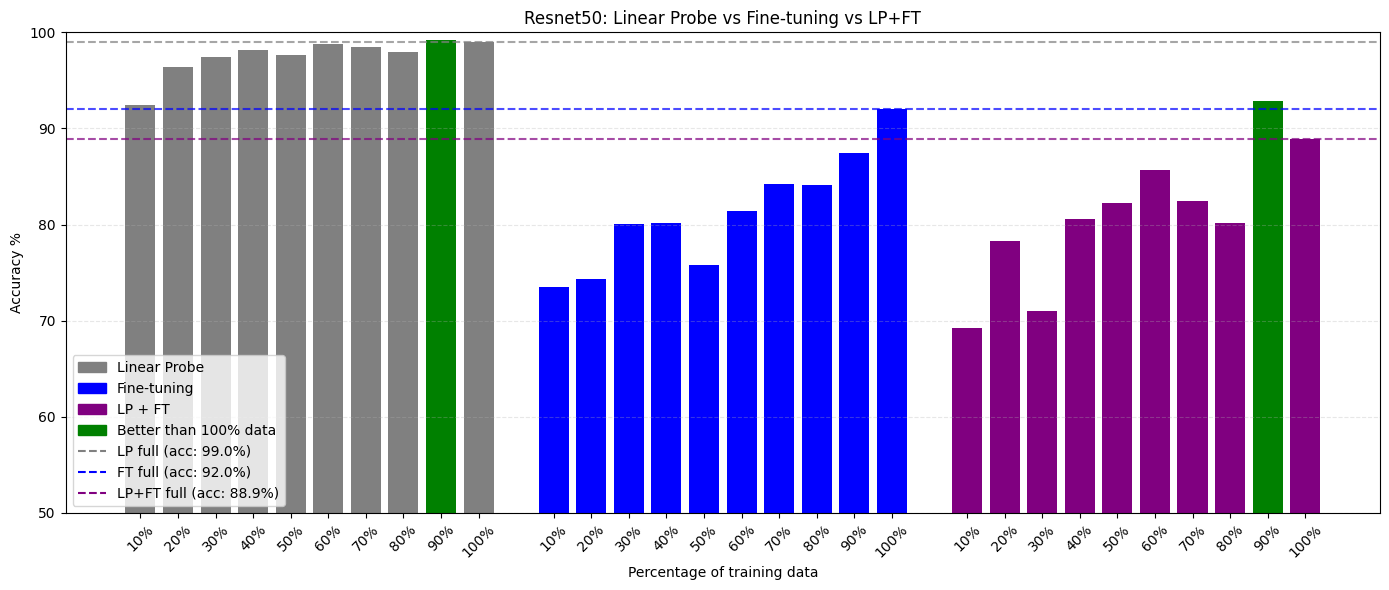

In [7]:
print("Linear Probing vs Fine-Tuning (Dino embedings)")
print("="*60)

#---------- treining modeli -------------
num_epochs = 10
lp_lr = 1e-2
ft_lr = 1e-3
batch_size = 64

percentages = [0.1, 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]
results = pd.DataFrame({
     "strategy": [],
     "percentage":[],
     "accuracy": [],
     "losses": [],
})

for p in percentages:
    label = f"{int(p * 100)}%"
    target_size = int(len(train_dataset) * p)
    print()
    print(f"Subset size: {target_size} / {len(train_dataset)} ({p*100}%)")

    if p < 1.0:
        idx = hs.hierarchical_sampling(cl_dino, target_size=target_size)
        current_ds = Subset(train_dataset, idx)
    else:
        current_ds = train_dataset
    #---------- linear probe ----------------
    set_seed(SEED)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad=False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model.to(device)
    criterion=nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lp_lr)

    acc, losses = train_model(model, criterion, optimizer,
                DataLoader(current_ds, batch_size=batch_size, shuffle=True,num_workers=0,
                            generator=torch.Generator().manual_seed(SEED)),
                test_loader,device, 
                "Linear Probe |",
                epochs = num_epochs, epoch_tqdm=True, loader_tqdm=False)
    new_row = pd.DataFrame({
        "strategy": ["LP"],
        "percentage":[label],
        "accuracy": [acc],
        "losses": [losses],
    })
    results = pd.concat([results,new_row],axis=0)

    #---------- fine-tuning -----------------
    set_seed(SEED)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    criterion=nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=ft_lr)
    model.to(device)
    acc, losses = train_model(model, criterion, optimizer,
                DataLoader(current_ds, batch_size=batch_size, shuffle=True,num_workers=0,
                            generator=torch.Generator().manual_seed(SEED)),
                test_loader,device, 
                "Fine-Tuning |",
                epochs = num_epochs, epoch_tqdm=True, loader_tqdm=False)
    
    new_row = pd.DataFrame({
        "strategy": ["FT"],
        "percentage":[label],
        "accuracy": [acc],
        "losses": [losses],
    })
    results = pd.concat([results,new_row],axis=0)

    # -------------- 1/2 linear probe + 1/2 fine-tining ----------------
    epochs_lp = int(num_epochs/2)
    epochs_ft = num_epochs - epochs_lp

    set_seed(SEED)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for params in model.parameters():
        params.requires_grad=False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    criterion=nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lp_lr)
    model.to(device)
    _, losses_lp = train_model(model, criterion, optimizer,
                DataLoader(current_ds, batch_size=batch_size, shuffle=True,num_workers=0,
                            generator=torch.Generator().manual_seed(SEED)),
                test_loader,device, 
                "Linear Probe + Fine Tuning | LP part",
                epochs = epochs_lp, epoch_tqdm=True, loader_tqdm=False)
    

    for params in model.parameters():
        params.requires_grad=True
    optimizer = optim.Adam(model.parameters(), lr=ft_lr)
    acc, losses_ft = train_model(model, criterion, optimizer,
                DataLoader(current_ds, batch_size=batch_size, shuffle=True,num_workers=0,
                            generator=torch.Generator().manual_seed(SEED)),
                test_loader,device, 
                "Linear Probe + Fine Tuning | FT part",
                epochs = epochs_ft, epoch_tqdm=True, loader_tqdm=False)
    losses = losses_lp + losses_ft

    new_row = pd.DataFrame({
        "strategy": ["LP+FT"],
        "percentage":[label],
        "accuracy": [acc],
        "losses": [losses],
    })
    results = pd.concat([results,new_row],axis=0)
    print()
    print("-"*60)

        
plt.figure(figsize=(14, 6))

lp = results[results["strategy"] == "LP"]
ft = results[results["strategy"] == "FT"]
lpft = results[results["strategy"] == "LP+FT"]

n = len(percentages)
x_lp = np.arange(n)
x_ft = np.arange(n + 1, 2 * n + 1)
x_lpft = np.arange(2 * n + 2, 3 * n + 2)

lp_full = lp["accuracy"].values[-1]
ft_full = ft["accuracy"].values[-1]
lpft_full = lpft["accuracy"].values[-1]

lp_colors = ['green' if a > lp_full else 'gray' for a in lp["accuracy"].values]
ft_colors = ['green' if a > ft_full else 'blue' for a in ft["accuracy"].values]
lpft_colors = ['green' if a > lpft_full else 'purple' for a in lpft["accuracy"].values]

plt.bar(x_lp, lp["accuracy"].values, color=lp_colors)
plt.bar(x_ft, ft["accuracy"].values, color=ft_colors)
plt.bar(x_lpft, lpft["accuracy"].values, color=lpft_colors)

plt.axhline(y=lp_full, linestyle='--', color='gray', alpha=0.7)
plt.axhline(y=ft_full, linestyle='--', color='blue', alpha=0.7)
plt.axhline(y=lpft_full, linestyle='--', color='purple', alpha=0.7)

legend_handles = [
    Patch(color='gray', label='Linear Probe'),
    Patch(color='blue', label='Fine-tuning'),
    Patch(color='purple', label='LP + FT'),
    Patch(color='green', label='Better than 100% data'),
    Line2D([0], [0], linestyle='--', color='gray', label=f'LP full (acc: {lp_full:.1f}%)'),
    Line2D([0], [0], linestyle='--', color='blue', label=f'FT full (acc: {ft_full:.1f}%)'),
    Line2D([0], [0], linestyle='--', color='purple', label=f'LP+FT full (acc: {lpft_full:.1f}%)'),
]
plt.legend(handles=legend_handles)

all_x = np.concatenate([x_lp, x_ft, x_lpft])
all_labels = list(lp["percentage"].values) + list(ft["percentage"].values) + list(lpft["percentage"].values)
plt.xticks(all_x, all_labels, rotation=45)

plt.xlabel('Percentage of training data')
plt.ylabel('Accuracy %')
plt.title('Resnet50: Linear Probe vs Fine-tuning vs LP+FT')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.ylim(50, 100)

plt.show()

Klastrowanie Hierarchiczne opare na embedingach z resnetu i Dino

In [8]:
print("\n---  Feature extraction and hierarchical k-means (resnet) ---")
set_seed(SEED)
resnet_embedings = get_resnet50_embedings(train_dataset).float()
clusters = hkmg.hierarchical_kmeans_with_resampling(
    data=resnet_embedings,                                                                           
    n_clusters=[100, 10],
    n_levels=2,
    sample_sizes=[65, 650],
    verbose=False,
)
cl_resnet = HierarchicalCluster.from_dict(clusters)


---  Feature extraction and hierarchical k-means (resnet) ---


Feature extraction: 100%|██████████| 74/74 [00:26<00:00,  2.83it/s]


Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  9.86it/s]


Experimenting with feature extraction for sampling | Dino vs Resnet50
Subset size: 946 / 9469 (10.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 4979.58it/s]

[TRENING] Start: Dino features |


Epochs: 100%|██████████| 10/10 [00:30<00:00,  3.07s/it]


[RESULT] Dino features | Accuracy: 92.48%

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 4983.73it/s]

[TRENING] Start: Resnet50 features |


Epochs: 100%|██████████| 10/10 [00:30<00:00,  3.04s/it]


[RESULT] Resnet50 features | Accuracy: 98.83%

------------------------------------------------------------

Subset size: 1893 / 9469 (20.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1331.82it/s]

[TRENING] Start: Dino features |


...

[RESULT] Resnet50 features | Accuracy: 99.08%

------------------------------------------------------------

Subset size: 9469 / 9469 (100.0%)


[TRENING] Start: Dino features |


Epochs: 100%|██████████| 10/10 [05:10<00:00, 31.04s/it]


[RESULT] Dino features | Accuracy: 98.96%


[TRENING] Start: Resnet50 features |


Epochs: 100%|██████████| 10/10 [05:10<00:00, 31.05s/it]


[RESULT] Resnet50 features | Accuracy: 98.96%

------------------------------------------------------------



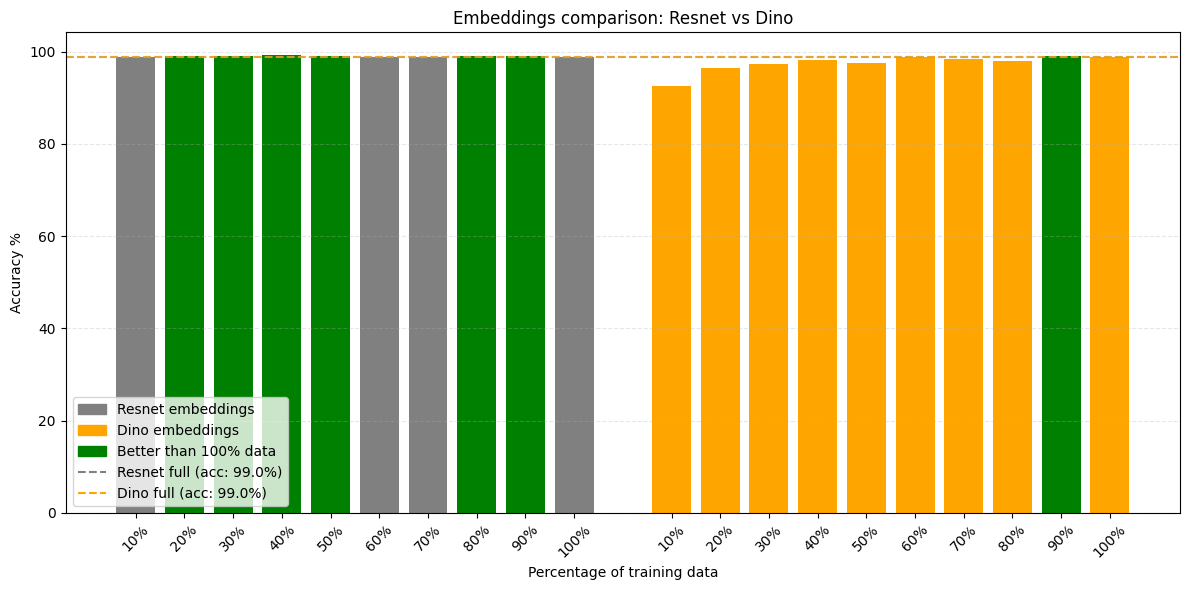

In [ ]:
print("Experimenting with feature extraction for sampling | Dino vs Resnet50")
print("="*60)

num_epochs = 10
lr = 1e-2
batch_size = 64

percentages = [0.1, 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0]
results_embedings = pd.DataFrame({
     "embedings": [],
     "percentage":[],
     "accuracy": [],
     "losses": [],
})

for p in percentages:
    label = f"{int(p * 100)}%"
    target_size = int(len(train_dataset) * p)
    print(f"Subset size: {target_size} / {len(train_dataset)} ({p*100}%)")
    print()
    
    if p < 1.0:
        idx = hs.hierarchical_sampling(cl_dino, target_size=target_size)
        current_ds = Subset(train_dataset, idx)
    else:
        current_ds = train_dataset

    # -------------- trening modelu (LP, sampling z dino) --------------------
    set_seed(SEED)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for params in model.parameters():
        params.requires_grad=False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    acc, losses = train_model(model, criterion, optimizer,
                            DataLoader(current_ds, batch_size=batch_size, shuffle=True, num_workers=0,
                                    generator=torch.Generator().manual_seed(SEED)),
                            test_loader, device,
                            "Dino features |",
                            epochs=num_epochs, epoch_tqdm=True, loader_tqdm=False
                            )

    new_row = pd.DataFrame({
        "embedings": ["Dino"],
        "percentage":[label],
        "accuracy": [acc],
        "losses": [losses],
    })
    results_embedings = pd.concat([results_embedings,new_row],axis=0)
    print()
    # -------------- trening modelu (LP, sampling z resnet50) --------------------
    if p < 1.0:
        idx = hs.hierarchical_sampling(cl_resnet, target_size=target_size)
        current_ds = Subset(train_dataset, idx)
    else:
        current_ds = train_dataset

    set_seed(SEED)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for params in model.parameters():
        params.requires_grad=False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    acc, losses= train_model(model, criterion, optimizer,
                            DataLoader(current_ds, batch_size=batch_size, shuffle=True, num_workers=0,
                                    generator=torch.Generator().manual_seed(SEED)),
                            test_loader, device,
                            "Resnet50 features |",
                            epochs=num_epochs, epoch_tqdm=True, loader_tqdm=False
                            )
    new_row = pd.DataFrame({
        "embedings": ["Resnet"],
        "percentage":[label],
        "accuracy": [acc],
        "losses": [losses],
    })
    results_embedings = pd.concat([results_embedings,new_row],axis=0)
    print()
    print("-"*60)
    print()


plt.figure(figsize=(12, 6))

resnet = results_embedings[results_embedings["embedings"] == "Resnet"]
dino = results_embedings[results_embedings["embedings"] == "Dino"]

n = len(percentages)
x_resnet = np.arange(n)
x_dino = np.arange(n + 1, 2 * n + 1)

resnet_full = resnet["accuracy"].values[-1]
dino_full = dino["accuracy"].values[-1]

resnet_colors = ['green' if a > resnet_full else 'gray' for a in resnet["accuracy"].values]
dino_colors = ['green' if a > dino_full else 'orange' for a in dino["accuracy"].values]

plt.bar(x_resnet, resnet["accuracy"].values, color=resnet_colors)
plt.bar(x_dino, dino["accuracy"].values, color=dino_colors)

plt.axhline(y=resnet_full, linestyle='--', color='gray', alpha=0.7)
plt.axhline(y=dino_full, linestyle='--', color='orange', alpha=0.7)

legend_handles = [
    Patch(color='gray', label='Resnet embeddings'),
    Patch(color='orange', label='Dino embeddings'),
    Patch(color='green', label='Better than 100% data'),
    Line2D([0], [0], linestyle='--', color='gray', label=f'Resnet full (acc: {resnet_full:.1f}%)'),
    Line2D([0], [0], linestyle='--', color='orange', label=f'Dino full (acc: {dino_full:.1f}%)'),
]
plt.legend(handles=legend_handles)

all_x = np.concatenate([x_resnet, x_dino])
all_labels = list(resnet["percentage"].values) + list(dino["percentage"].values)
plt.xticks(all_x, all_labels, rotation=45)

plt.xlabel('Percentage of training data')
plt.ylabel('Accuracy %')
plt.title('Embeddings comparison: Resnet vs Dino')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()



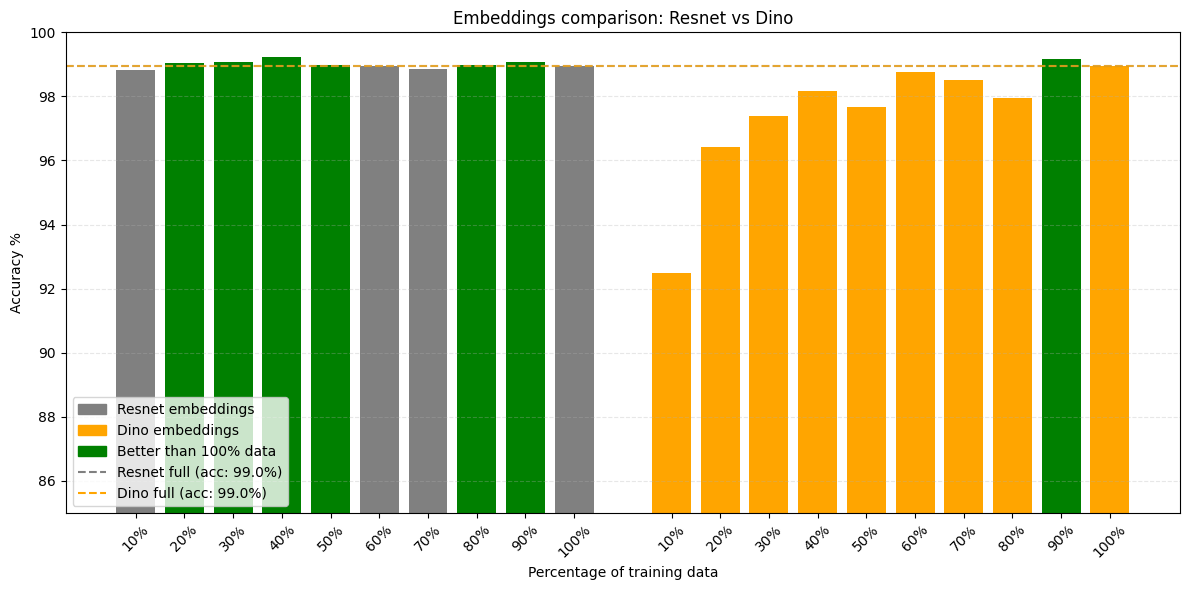

In [21]:
plt.figure(figsize=(12, 6))

resnet = results_embedings[results_embedings["embedings"] == "Resnet"]
dino = results_embedings[results_embedings["embedings"] == "Dino"]

n = len(percentages)
x_resnet = np.arange(n)
x_dino = np.arange(n + 1, 2 * n + 1)

resnet_full = resnet["accuracy"].values[-1]
dino_full = dino["accuracy"].values[-1]

resnet_colors = ['green' if a > resnet_full else 'gray' for a in resnet["accuracy"].values]
dino_colors = ['green' if a > dino_full else 'orange' for a in dino["accuracy"].values]

plt.bar(x_resnet, resnet["accuracy"].values, color=resnet_colors)
plt.bar(x_dino, dino["accuracy"].values, color=dino_colors)

plt.axhline(y=resnet_full, linestyle='--', color='gray', alpha=0.7)
plt.axhline(y=dino_full, linestyle='--', color='orange', alpha=0.7)

legend_handles = [
    Patch(color='gray', label='Resnet embeddings'),
    Patch(color='orange', label='Dino embeddings'),
    Patch(color='green', label='Better than 100% data'),
    Line2D([0], [0], linestyle='--', color='gray', label=f'Resnet full (acc: {resnet_full:.1f}%)'),
    Line2D([0], [0], linestyle='--', color='orange', label=f'Dino full (acc: {dino_full:.1f}%)'),
]
plt.legend(handles=legend_handles)

all_x = np.concatenate([x_resnet, x_dino])
all_labels = list(resnet["percentage"].values) + list(dino["percentage"].values)
plt.xticks(all_x, all_labels, rotation=45)

plt.xlabel('Percentage of training data')
plt.ylabel('Accuracy %')
plt.title('Embeddings comparison: Resnet vs Dino')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.ylim(85,100)

plt.show()

Próba dla skewed dataset dla embedingów dino

In [10]:
class CifarArrowDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform=None):
        # !!! ważne dataset w argumencie to huggingface datasets.Dataset
        self.ds = dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img, label = item['img'], item['fine_label']
        if self.transform:
            img = self.transform(img)
        return img, label

In [11]:
DEBUG = False
DEBUG_SIZE = 700

In [12]:
print("--- Loading skewed dataset ---")
skewed_dataset_dict = load_dataset("tomas-gajarsky/cifar100-lt", "r-50", cache_dir="../data")
train_dataset_skewed = CifarArrowDataset(skewed_dataset_dict["train"],ResnetTransform())
test_dataset_skewed = CifarArrowDataset(skewed_dataset_dict["test"],ResnetTransform())
train_dataset_dino_skewed = CifarArrowDataset(skewed_dataset_dict["train"],DinoTransform())

--- Loading skewed dataset ---


In [13]:
if DEBUG:
    train_dataset_skewed = Subset(train_dataset_skewed, range(min(DEBUG_SIZE, len(train_dataset_skewed))))
    test_dataset_skewed = Subset(test_dataset_skewed, range(min(DEBUG_SIZE, len(test_dataset_skewed))))
    train_dataset_dino_skewed = Subset(train_dataset_dino_skewed, range(min(DEBUG_SIZE, len(train_dataset_dino_skewed))))

In [14]:
print("\n--- Feature extraction and hierarchical k-means on skewed dataset (dino) ---")
set_seed(SEED)
dino_embedings_skewed = get_dino_embedings(train_dataset_dino_skewed).float()
clusters_dino_skewed = hkmg.hierarchical_kmeans_with_resampling(
    data=dino_embedings_skewed,                                                                           
    n_clusters=[100, 10],
    n_levels=2,
    sample_sizes=[65, 650],
    verbose=False,
)
cl_dino_skewed = HierarchicalCluster.from_dict(clusters_dino_skewed)


--- Feature extraction and hierarchical k-means on skewed dataset (dino) ---


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Feature extraction: 100%|██████████| 99/99 [01:35<00:00,  1.03it/s]


Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:00<00:00, 10.20it/s]


Testing sampling with Dino features on a skewed dataset

Subset size: 1260 / 12608 (10.0%)
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 630.44it/s]

[TRENING] Start: Training on skewed data with sampling using Dino embedings | subset: 1260 / 12608 (10.0%)


Epochs: 100%|██████████| 10/10 [00:21<00:00,  2.14s/it]


[RESULT] Training on skewed data with sampling using Dino embedings | subset: 1260 / 12608 (10.0%) Accuracy: 7.59%

------------------------------------------------------------

Subset size: 2521 / 12608 (20.0%)
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<?, ?it/s]

[TRENING] Start: Training on skewed data with sampling using Dino embedings | subset: 2521 / 12608 (20.0%)


Epochs: 100%|██████████| 10/10 [00:41<00:00,  4.19s/it]


[RESULT] Training on skewed data with sampling using Dino embedings | subset: 2521 / 12608 (20.0%) Accuracy: 15.25%

------------------------------------------------------------

Subset size: 3782 / 12608 (30.0%)
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 4981.95it/s]

[TRENING] Start: Training on skewed data with sampling using Dino embedings | subset: 3782 / 12608 (30.0%)


...

[RESULT] Training on skewed data with sampling using Dino embedings | subset: 10086 / 12608 (80.0%) Accuracy: 32.10%

------------------------------------------------------------

Subset size: 11347 / 12608 (90.0%)
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<?, ?it/s]

[TRENING] Start: Training on skewed data with sampling using Dino embedings | subset: 11347 / 12608 (90.0%)


Epochs: 100%|██████████| 10/10 [03:09<00:00, 18.98s/it]


[RESULT] Training on skewed data with sampling using Dino embedings | subset: 11347 / 12608 (90.0%) Accuracy: 34.70%

------------------------------------------------------------

Subset size: 12608 / 12608 (100%)

[TRENING] Start: Training on skewed data with sampling using Dino embedings | subset: 12608 / 12608 (100%)


Epochs: 100%|██████████| 10/10 [03:32<00:00, 21.27s/it]


[RESULT] Training on skewed data with sampling using Dino embedings | subset: 12608 / 12608 (100%) Accuracy: 37.33%

------------------------------------------------------------



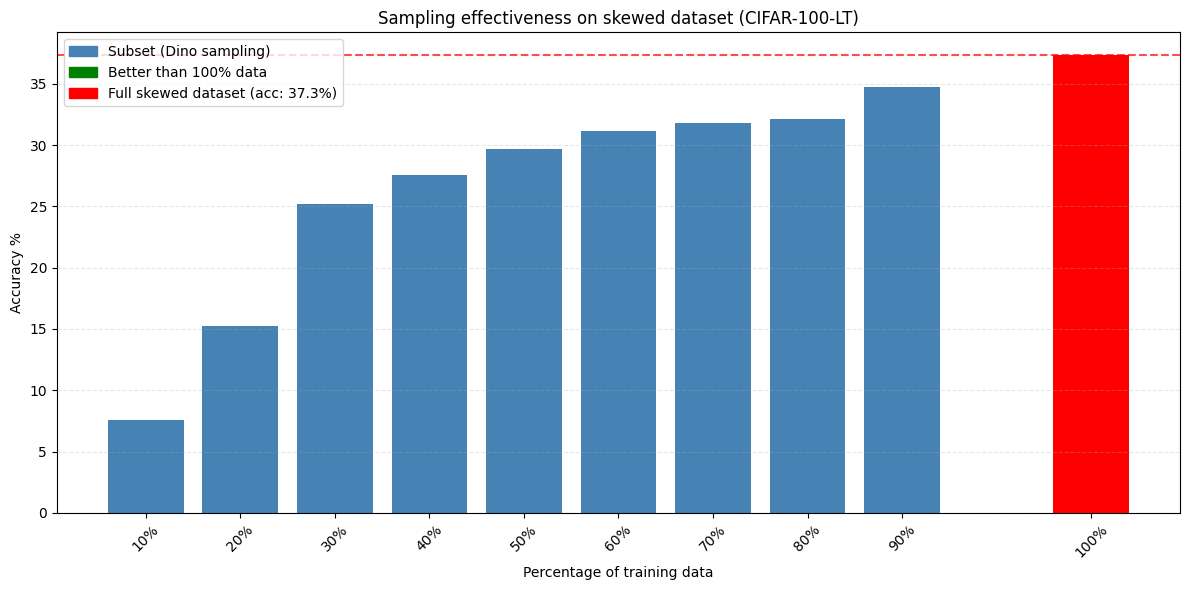

In [15]:
print("Testing sampling with Dino features on a skewed dataset")
print("="*60)
print()

batch_size = 64
lr = 1e-3 # 1e-2?
num_epochs = 10
test_loader_skewed = DataLoader(test_dataset_skewed, batch_size=batch_size, shuffle=False)

percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,1]

if DEBUG:
       num_epochs = 1
       percentages = [0.5,0.9,1]

results_skewed = pd.DataFrame({
     "percentage":[],
     "accuracy": [],
     "losses": [],
})

for p in percentages:
    label = f"{int(p * 100)}%"
    target_size = int(len(train_dataset_skewed) * p)
    print(f"Subset size: {target_size} / {len(train_dataset_skewed)} ({p*100}%)")

    if p < 1.0:
        idx = hs.hierarchical_sampling(cl_dino_skewed, target_size=target_size)
        current_ds = Subset(train_dataset_skewed, idx)
    else:
        current_ds = train_dataset_skewed

    # -------------- trening modelu na skewed dataset (LP, sampling z dino) ------------

    set_seed(SEED)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for params in model.parameters():
        params.requires_grad=False
    model.fc = nn.Linear(model.fc.in_features, 100)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    acc, losses= train_model(model, criterion, optimizer,
                            DataLoader(current_ds, batch_size=batch_size, shuffle=True, num_workers=0,
                                    generator=torch.Generator().manual_seed(SEED)),
                            test_loader_skewed, device,
                            f"Training on skewed data with sampling using Dino embedings | subset: {target_size} / {len(train_dataset_skewed)} ({p*100}%)",
                            epochs=num_epochs, epoch_tqdm=True, loader_tqdm=False
                            )
    
    new_row = pd.DataFrame({
        "percentage":[label],
        "accuracy": [acc],
        "losses": [losses],
    })
    results_skewed = pd.concat([results_skewed,new_row],axis=0)
    print()
    print("-"*60)
    print()

plt.figure(figsize=(12, 6))

n = len(percentages)
x = np.arange(n)

full_acc = results_skewed["accuracy"].values[-1]
colors = ['green' if a > full_acc else 'steelblue' for a in results_skewed["accuracy"].values]
colors[-1] = 'red'  # 100% osobno

# gap przed ostatnim słupkiem
x[-1] += 1

plt.bar(x, results_skewed["accuracy"].values, color=colors)
plt.axhline(y=full_acc, linestyle='--', color='red', alpha=0.7)

legend_handles = [
    Patch(color='steelblue', label='Subset (Dino sampling)'),
    Patch(color='green', label='Better than 100% data'),
    Patch(color='red', label=f'Full skewed dataset (acc: {full_acc:.1f}%)'),
]
plt.legend(handles=legend_handles)

plt.xticks(x, results_skewed["percentage"].values, rotation=45)
plt.xlabel('Percentage of training data')
plt.ylabel('Accuracy %')
plt.title('Sampling effectiveness on skewed dataset (CIFAR-100-LT)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()
